In [1]:
import pandas as pd
import numpy as np
import os
import joblib 

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
%matplotlib inline

print(os.listdir("../data"))
data_path = "../data/pipe_conditions.csv"

import warnings
warnings.filterwarnings('ignore')

['processed', 'raw']


In [11]:
Seed = 42
np.random.seed(Seed)

In [4]:
#Load Data
base_path = os.path.dirname(os.getcwd()) 
data_path = os.path.join(base_path, 'data', 'raw', 'pipe_condition_class_synthetic.csv')

df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               30000 non-null  int64  
 1   Material          30000 non-null  str    
 2   Diameter          30000 non-null  int64  
 3   Slope             30000 non-null  float64
 4   Depth             30000 non-null  float64
 5   Length            30000 non-null  float64
 6   Soil PH           30000 non-null  float64
 7   Soil Type         30000 non-null  str    
 8   Road Type         30000 non-null  str    
 9   Condition Rating  30000 non-null  int64  
dtypes: float64(4), int64(3), str(3)
memory usage: 2.3 MB


In [13]:
df.head()

,Age,Material,Diameter,Slope,Depth,Length,Soil PH,Soil Type,Road Type,Condition Rating
0,57,VCP,8,0.34,11.32,221.045734,5.7,Rock,Street,3
1,35,VCP,12,0.40,7.00,342.975986,6.8,Clay,Street,5
2,28,PVC,8,0.50,8.58,295.072420,5.4,Sand,Street,1
3,31,PVC,15,0.17,10.50,492.085601,8.2,Clay,Street,1
4,58,PVC,8,0.36,8.58,334.559947,8.2,Clay,Alley,3


In [14]:
df.describe()

,Age,Diameter,Slope,Depth,Length,Soil PH,Condition Rating
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,47.651267,11.278667,0.779142,8.427552,280.989532,6.870208,2.105267
std,20.719162,9.304710,1.329829,3.160971,194.936076,1.309579,1.199458
min,5.000000,6.000000,0.000000,0.090000,5.764852,4.100000,1.000000
25%,30.000000,8.000000,0.300000,7.000000,160.173861,5.700000,1.000000
50%,51.000000,8.000000,0.400000,8.000000,261.116710,7.500000,2.000000
75%,65.000000,10.000000,0.670000,10.000000,336.869356,8.200000,3.000000
max,121.000000,90.000000,52.897268,77.277406,2245.996774,8.200000,5.000000


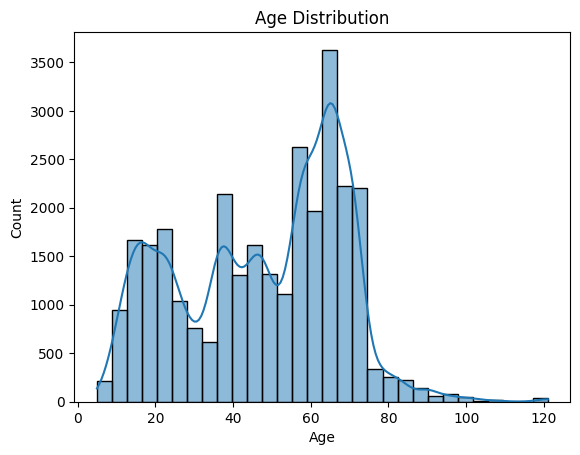

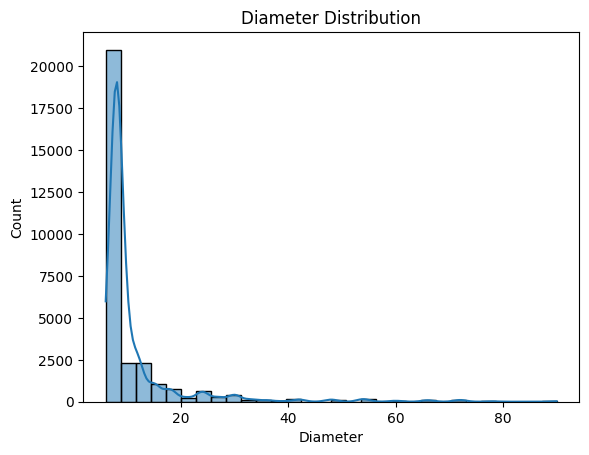

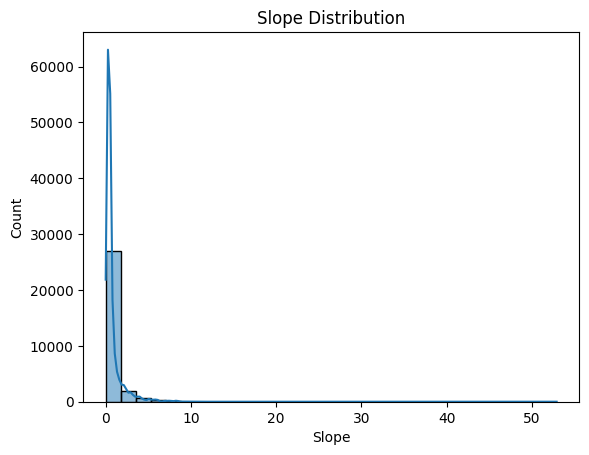

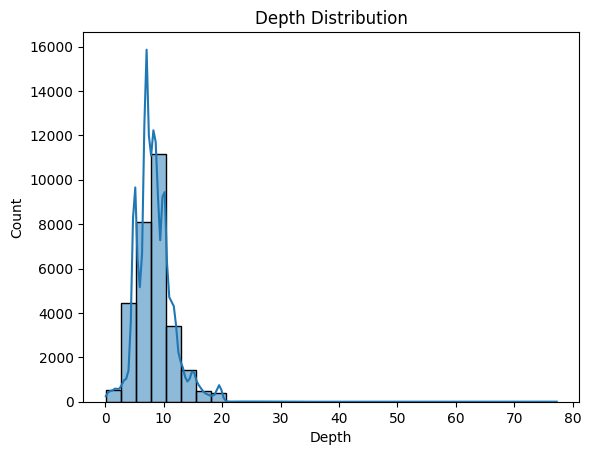

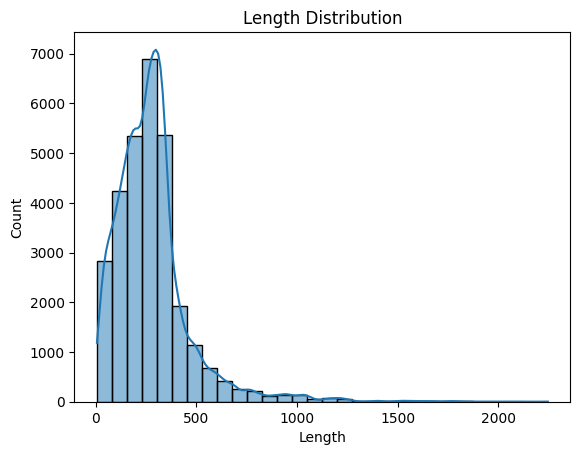

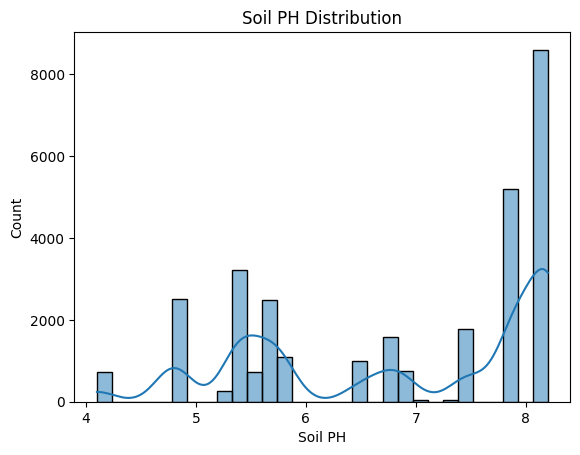

In [15]:
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

sns.histplot(df['Diameter'], bins=30, kde=True)
plt.title('Diameter Distribution')
plt.show()

sns.histplot(df['Slope'], bins=30, kde=True)
plt.title('Slope Distribution')
plt.show()

sns.histplot(df['Depth'], bins=30, kde=True)
plt.title('Depth Distribution')
plt.show()

sns.histplot(df['Length'], bins=30, kde=True)
plt.title('Length Distribution')
plt.show()

sns.histplot(df['Soil PH'], bins=30, kde=True)
plt.title('Soil PH Distribution')
plt.show()

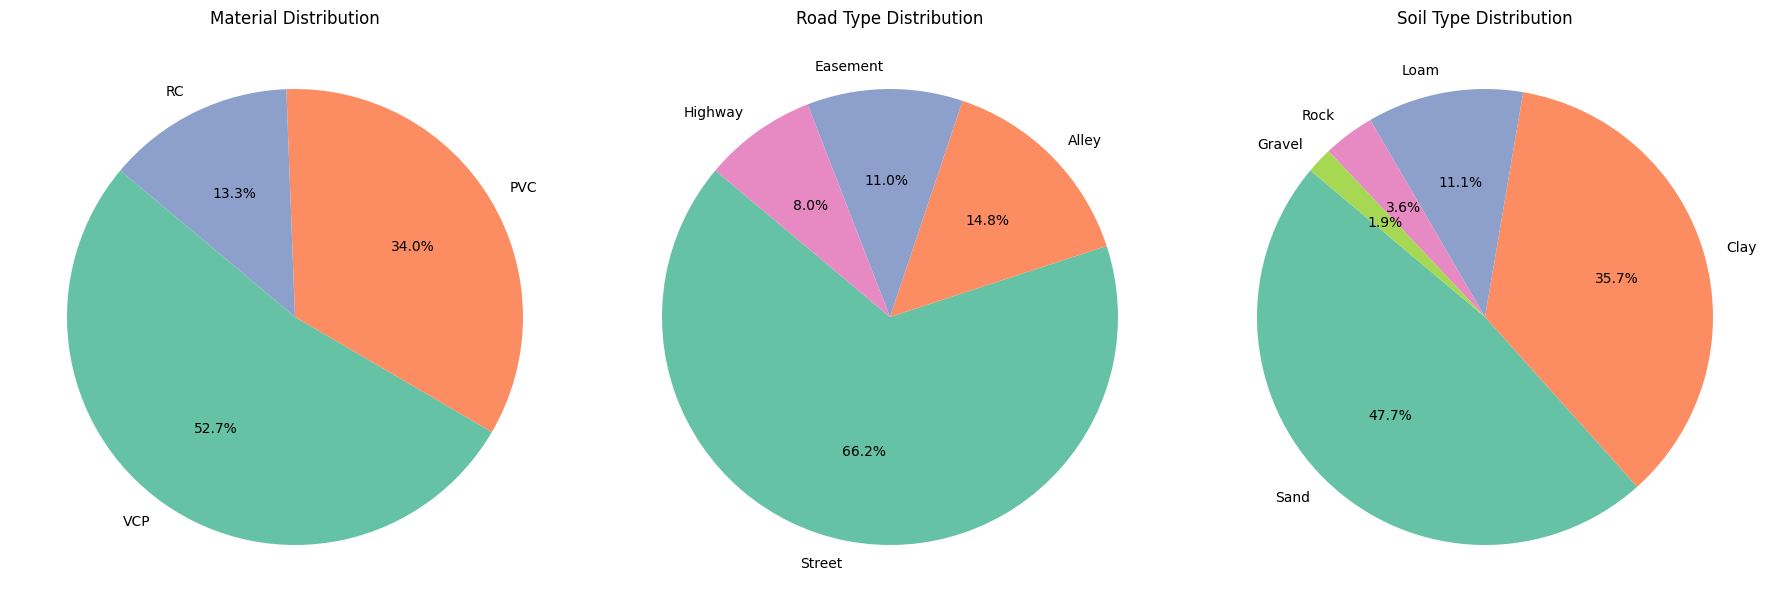

In [74]:
cat_cols = ['Material', 'Road Type', 'Soil Type']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(
        counts, 
        labels=counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('Set2')
    )
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

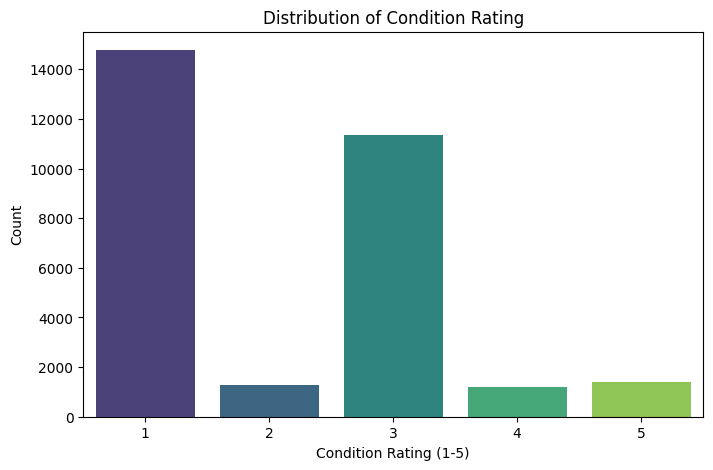

In [73]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Condition Rating', palette='viridis')
plt.title('Distribution of Condition Rating')
plt.xlabel('Condition Rating (1-5)')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.02, 'Pairplot of Features by Condition Rating')

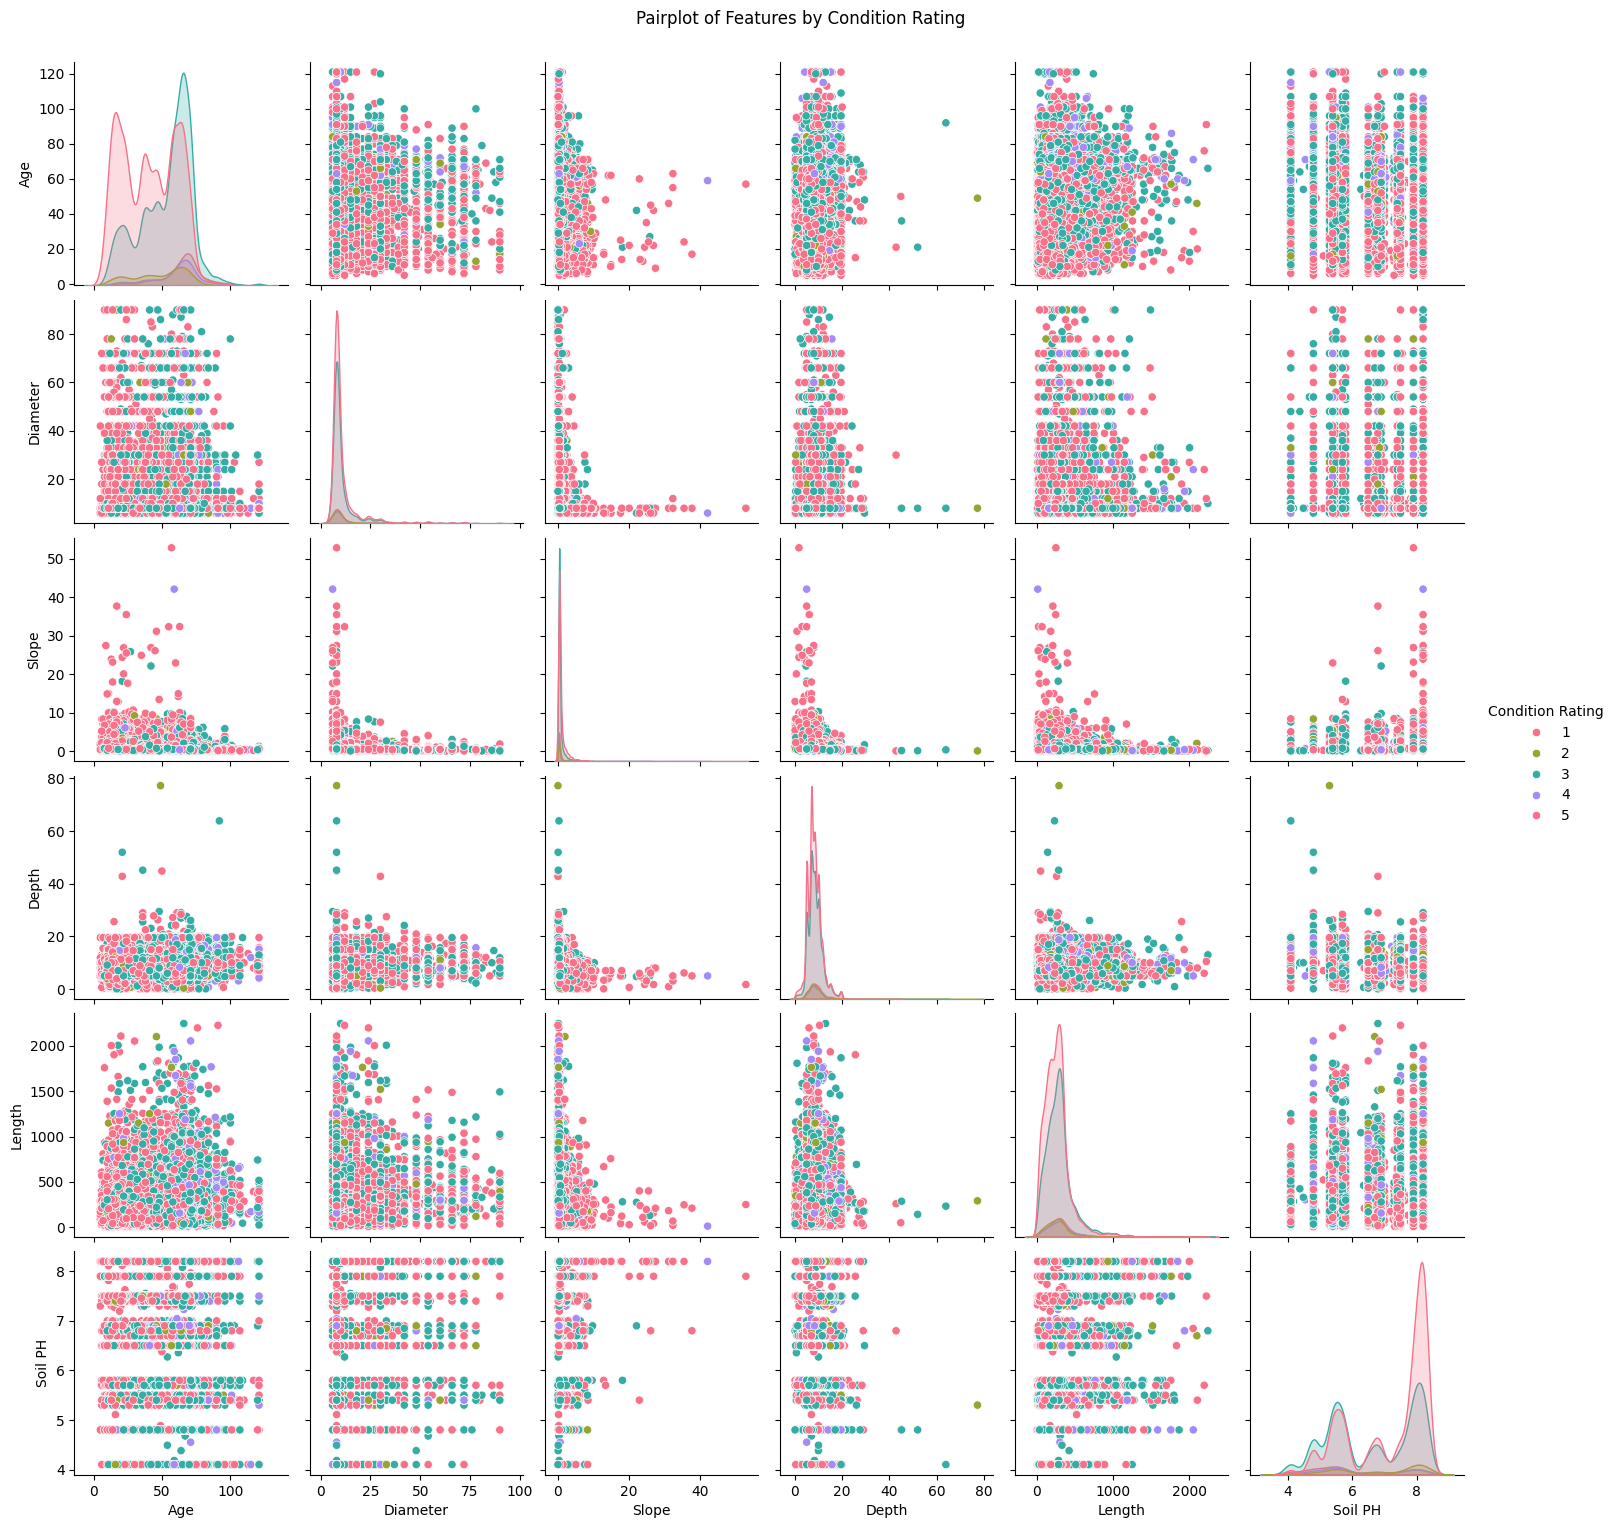

In [16]:
g = sns.pairplot(df, hue="Condition Rating", palette="husl")
g.fig.suptitle("Pairplot of Features by Condition Rating", y=1.02)

In [75]:
numerical_cols = ['Age', 'Diameter', 'Slope', 'Depth', 'Length', 'Soil PH']
stats_list = []
for col in numerical_cols:
    col_skew = df[col].skew()
    col_kurt = df[col].kurtosis()    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    
    stats_list.append({
        'Feature': col,
        'Outlier %': round(outlier_pct, 2),
        'Skewness': round(col_skew, 2),
        'Kurtosis': round(col_kurt, 2)
    })

stats_df = pd.DataFrame(stats_list)
display(stats_df) 

,Feature,Outlier %,Skewness,Kurtosis
0,Age,0.14,-0.19,-0.82
1,Diameter,14.62,4.35,22.47
2,Slope,14.16,10.49,232.61
3,Depth,6.52,1.64,15.46
4,Length,5.30,2.51,11.85
5,Soil PH,0.00,-0.44,-1.33


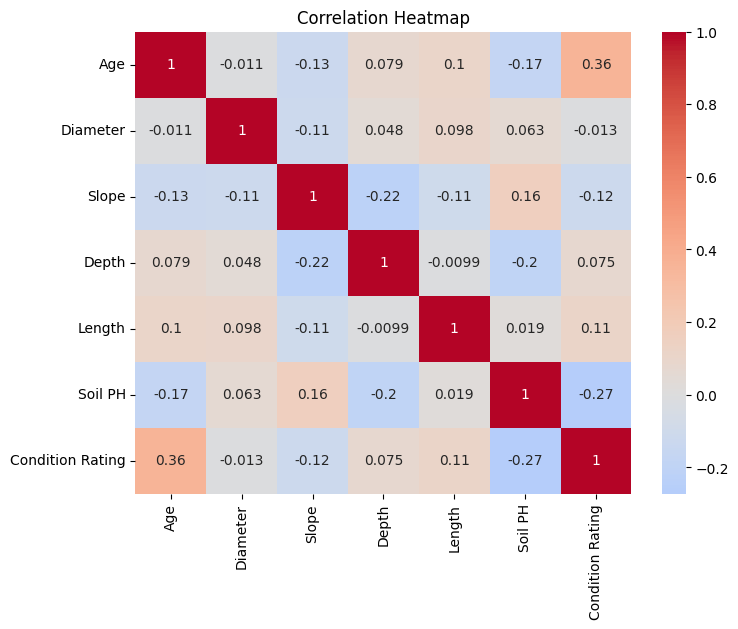

In [18]:
#Correlation Heartmap
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, KFold
"from sklearn.pipeline import Pipeline"
from imblearn.pipeline import Pipeline as ImbPipeline 
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [5]:
#Create Features and Target Variable
x = df.drop('Condition Rating', axis = 1)
y = df['Condition Rating']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

#Split Categorical and Numerical Features (Seperate heavily skewed from standard)
skewed_num_cols = ['Diameter', 
                   'Slope', 
                   'Depth', 
                   'Length']
standard_num_cols = ['Age', 
                    'Soil PH']
categorical_cols = ['Material',
                    'Road Type', 
                    'Soil Type'
                    ]

#Training and Testing Datasets
X_train, X_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (24000, 9)
Testing features shape: (6000, 9)


In [6]:

#Imputation & Encoding, Scaling, and Model Pipeline
skewed_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p, validate=False, feature_names_out='one-to-one')),
    ('scaler', RobustScaler())
])

standard_num_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_pipeline = ImbPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), 
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('skewed', skewed_pipeline, skewed_num_cols),
    ('standard', standard_num_pipeline, standard_num_cols),
    ('cat', categorical_pipeline, categorical_cols)
    ], verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression()) 
])

param_grid = [
    {
        'model': [RandomForestClassifier(class_weight='balanced', random_state=42)],
        'model__n_estimators': [100, 200],
        'model__max_depth': [10, 20, None]
    },
    {
        'model': [HistGradientBoostingClassifier(class_weight='balanced', random_state=42)],
        'model__max_depth': [5, 10, None]
    },
    {
        'model': [LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)],
        'model__C': [0.1, 1.0, 10.0]
    },
    {
        'model': [SVC(class_weight='balanced', random_state=42)],
        'model__C': [0.1, 1.0, 10.0],
        'model__kernel': ['linear', 'rbf']
    },
    {
        'model': [KNeighborsClassifier()],
        'model__n_neighbors': [3, 5, 7],
        'model__weights': ['uniform', 'distance']
    },
    {
        'model': [AdaBoostClassifier(random_state=42)],
        'model__n_estimators': [50, 100],
        'model__learning_rate': [0.01,0.1,0.2, 1.0]
    },
    {
      'model': [XGBClassifier(random_state=42, eval_metric='mlogloss')],
      'model__n_estimators': [50,100, 200],  
      'model__learning_rate': [0.01, 0.1, 0.2, 1.0]
    },
    {
        'model': [GaussianNB()] 
    },
    {
        'model': [LinearDiscriminantAnalysis()]
    },
    {
        'model': [DecisionTreeClassifier(class_weight='balanced', random_state=42)],
        'model__max_depth': [5, 10, None]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1, 
    verbose=1  ,
    error_score='raise'
)

In [24]:
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values(by='rank_test_score')

for index , row in cv_results.iterrows():
    mean_score = row['mean_test_score']
    std_score = row['std_test_score']
    params = row['params']
    
    model_name = params['model'].__class__.__name__
    
    clean_params = {k: v for k, v in params.items() if k != 'model'}
    
    print(f"Model: {model_name}")
    print(f"CV F1_Score: {mean_score:.4f} (+/- {std_score:.4f})")
    print(f"Hyperparameters: {clean_params}")
    print("-" * 40)

print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"Best Model Parameters: \n{grid_search.best_params_['model']}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 49 candidates, totalling 245 fits
Model: XGBClassifier
CV F1_Score: 0.2879 (+/- 0.0021)
Hyperparameters: {'model__learning_rate': 0.1, 'model__n_estimators': 100}
----------------------------------------
Model: XGBClassifier
CV F1_Score: 0.2873 (+/- 0.0063)
Hyperparameters: {'model__learning_rate': 0.2, 'model__n_estimators': 50}
----------------------------------------
Model: RandomForestClassifier
CV F1_Score: 0.2854 (+/- 0.0077)
Hyperparameters: {'model__max_depth': 20, 'model__n_estimators': 200}
----------------------------------------
Model: RandomForestClassifier
CV F1_Score: 0.2852 (+/- 0.0046)
Hyperparameters: {'model__max_depth': 10, 'model__n_estimators': 100}
----------------------------------------
Model: XGBClassifier
CV F1_Score: 0.2849 (+/- 0.0036)
Hyperparameters: {'model__learning_rate': 0.1, 'model__n_estimators': 50}
----------------------------------------
Model: RandomForestClassifier
CV F1_Score: 0.2836 (+/- 0.0057)
Hyperparameters: {'

In [7]:

param_grid = [
    {
        'model': [XGBClassifier(eval_metric='mlogloss', random_state=42)],
        'model__n_estimators': [50, 100, 200, 300],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0]
    }
]

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_macro',
    n_jobs=-1, 
    verbose=1,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model': [XGBClassifier...ree=None, ...)], 'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.01, 0.1, ...], 'model__max_depth': [3, 5, ...], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : t

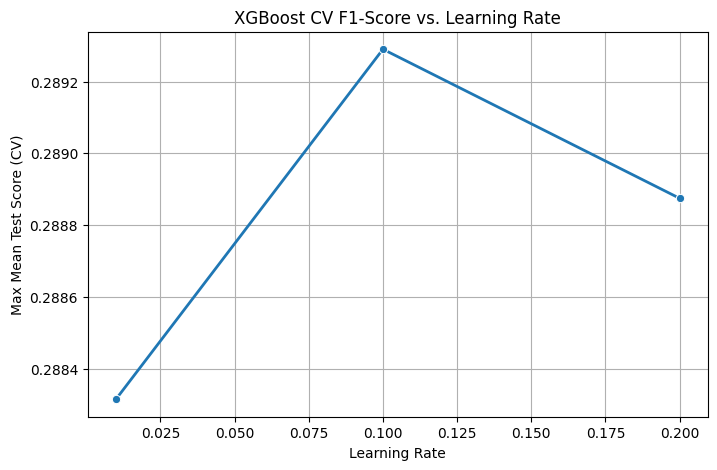

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cv_results = pd.DataFrame(grid_search.cv_results_)
xgb_results = cv_results[cv_results['param_model'].astype(str).str.contains('XGBClassifier')].copy()
lr_scores = xgb_results.groupby('param_model__learning_rate')['mean_test_score'].max().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=lr_scores, 
    x='param_model__learning_rate', 
    y='mean_test_score', 
    marker='o',
    linewidth=2
)

plt.title('XGBoost CV F1-Score vs. Learning Rate')
plt.xlabel('Learning Rate')
plt.ylabel('Max Mean Test Score (CV)')
plt.grid(True)
plt.show()

In [9]:
best_xgb_model = grid_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
test_accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
test_report_xgb = classification_report(y_test, y_pred_xgb)
print(f"XGBoost Test Set Accuracy: {test_accuracy_xgb:.4f}")
print("\nXGBoost Classification Report:")
print(test_report_xgb)

XGBoost Test Set Accuracy: 0.5407

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.72      0.69      2958
           1       0.07      0.02      0.02       265
           2       0.50      0.44      0.47      2289
           3       0.11      0.10      0.11       221
           4       0.17      0.29      0.21       267

    accuracy                           0.54      6000
   macro avg       0.30      0.31      0.30      6000
weighted avg       0.53      0.54      0.53      6000



<Figure size 1000x600 with 0 Axes>

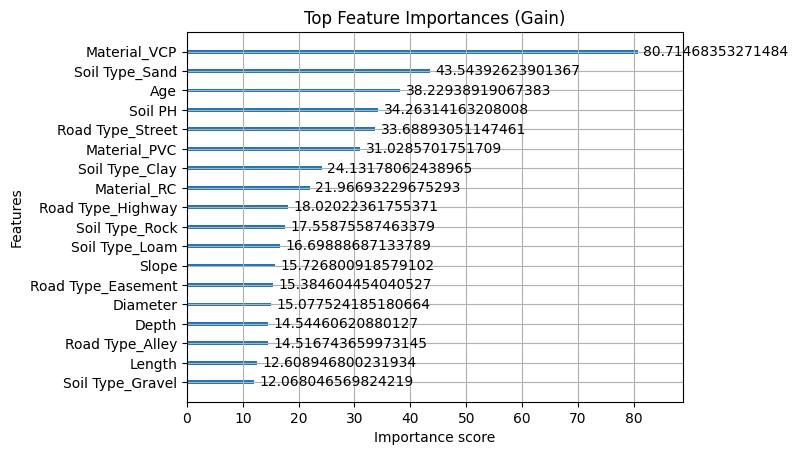

In [10]:
import xgboost
import matplotlib.pyplot as plt

clean_feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()
booster = best_xgb_model.named_steps['model'].get_booster()
booster.feature_names = list(clean_feature_names)

plt.figure(figsize=(10, 6))
xgboost.plot_importance(booster, importance_type='gain')
plt.title('Top Feature Importances (Gain)')
plt.show()

In [11]:
import pandas as pd
from imblearn.over_sampling import SMOTE

X_train_processed = preprocessor.fit_transform(X_train)
clean_feature_names = preprocessor.get_feature_names_out()
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)
processed_df = pd.DataFrame(X_train_smote, columns=clean_feature_names)
processed_df['Condition Rating'] = y_train_smote

processed_df.to_csv('processed_smote_data.csv', index=False)

print(f"Original Training Rows: {len(X_train)}")
print(f"New SMOTE Training Rows: {len(processed_df)}")

Original Training Rows: 24000
New SMOTE Training Rows: 59090


In [72]:
joblib.dump(grid_search.best_estimator_, 'best_xgb_model.joblib')

['best_xgb_model.joblib']